# 03 - Descriptive Analysis: What Happened?
Executive-friendly descriptive analysis using Plotly, Seaborn, and Matplotlib.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
print('Libraries loaded')

Libraries loaded


In [2]:
# Load data (parse dates)
df = pd.read_excel('D:/Downloads/2024-05-marketing-campaign-analysis/Marketing Campaign Analysis Dataset_May 2024.xlsx', parse_dates=['Date'])
df['Date'] = pd.to_datetime(df['Date'])
print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Dataset loaded: 9900 rows, 18 columns


,Campaign,Date,City/Location,Latitude,Longitude,Channel,Device,Ad,Impressions,"CTR, %",Clicks,Daily Average CPC,"Spend, GBP",Conversions,"Total conversion value, GBP",Likes (Reactions),Shares,Comments
0,Spring,2023-03-01,Birmingham,52.49,-1.90,Facebook,Desktop,Collection,"1,110.80",0.02,20.55,1.39,28.60,1,51.84,45.00,4.00,3.00
1,Spring,2023-03-02,Birmingham,52.49,-1.90,Facebook,Desktop,Collection,"1,296.60",0.01,14.26,0.72,10.33,2,40.32,14.00,17.00,10.50
2,Spring,2023-03-03,Birmingham,52.49,-1.90,Facebook,Desktop,Collection,"1,264.40",0.01,16.69,0.38,6.33,4,53.76,24.00,1.00,7.50
3,Spring,2023-03-04,Birmingham,52.49,-1.90,Facebook,Desktop,Collection,837.80,0.02,13.32,0.57,7.66,3,25.92,59.00,10.00,6.00
4,Spring,2023-03-05,Birmingham,52.49,-1.90,Facebook,Desktop,Collection,"1,599.00",0.01,23.03,0.83,19.07,2,108.19,44.00,17.00,1.50


## Executive KPIs
High-level metrics to answer: how many impressions, clicks, conversions, spend, CTR, ROI?

In [3]:
total_impr = int(df['Impressions'].sum())
total_clicks = int(df['Clicks'].sum())
total_conv = int(df['Conversions'].sum())
total_spend = df['Spend, GBP'].sum()
total_value = df['Total conversion value, GBP'].sum()
overall_ctr = df['CTR, %'].mean()
overall_conv_rate = (df['Conversions'].sum() / df['Clicks'].sum() * 100) if df['Clicks'].sum() > 0 else 0
overall_roi = ((total_value - total_spend) / total_spend * 100) if total_spend>0 else 0
print('--- EXECUTIVE KPIS ---')
print(f'Total Impressions: {total_impr:,}')
print(f'Total Clicks: {total_clicks:,}')
print(f'Total Conversions: {total_conv:,}')
print(f'Total Spend (GBP): £{total_spend:,.2f}')
print(f'Total Conversion Value (GBP): £{total_value:,.2f}')
print(f'Average CTR: {overall_ctr:.2f}%')
print(f'Overall Conversion Rate: {overall_conv_rate:.2f}%')
print(f'Overall ROI: {overall_roi:.2f}%')

--- EXECUTIVE KPIS ---
Total Impressions: 14,645,448
Total Clicks: 181,586
Total Conversions: 40,252
Total Spend (GBP): £163,250.07
Total Conversion Value (GBP): £1,731,700.44
Average CTR: 0.01%
Overall Conversion Rate: 22.17%
Overall ROI: 960.77%


## Time Series: Trends over time
Show daily/weekly trends for Impressions, Clicks, Conversions, Spend — use Plotly for interactivity and Matplotlib for static snapshot.

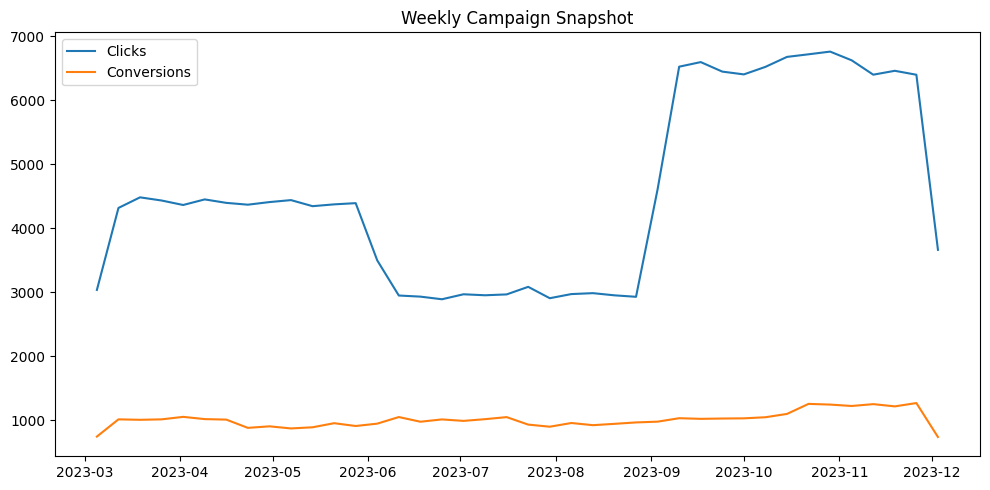

In [4]:
# Aggregate by Date (daily)
ts = df.groupby('Date').agg({
    'Impressions': 'sum',
    'Clicks': 'sum',
    'Conversions': 'sum',
    'Spend, GBP': 'sum'
}).reset_index()

# Plotly interactive multi-line
fig_ts = go.Figure()
fig_ts.add_trace(go.Scatter(x=ts['Date'], y=ts['Impressions'], mode='lines+markers', name='Impressions'))
fig_ts.add_trace(go.Scatter(x=ts['Date'], y=ts['Clicks'], mode='lines+markers', name='Clicks'))
fig_ts.add_trace(go.Scatter(x=ts['Date'], y=ts['Conversions'], mode='lines+markers', name='Conversions'))
fig_ts.add_trace(go.Scatter(x=ts['Date'], y=ts['Spend, GBP'], mode='lines+markers', name='Spend (GBP)'))
fig_ts.update_layout(title='Daily Campaign Trends', xaxis_title='Date', yaxis_title='Count / GBP', template='plotly_white', height=600)
fig_ts.show()

# Static Matplotlib snapshot (weekly sums)
ts_week = ts.set_index('Date').resample('W').sum()
plt.figure(figsize=(10,5))
# plt.plot(ts_week.index, ts_week['Impressions'], label='Impressions')
plt.plot(ts_week.index, ts_week['Clicks'], label='Clicks')
plt.plot(ts_week.index, ts_week['Conversions'], label='Conversions')
plt.legend()
plt.title('Weekly Campaign Snapshot')
plt.tight_layout()
plt.show()

## Top-level comparisons by Campaign / Channel / Device
Use bar charts to show what worked best.

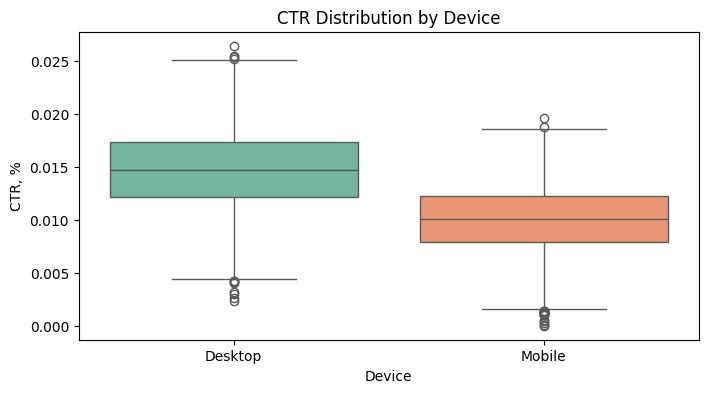

In [5]:
# Top campaigns by conversions and ROI
camp = df.groupby('Campaign').agg({'Impressions':'sum','Clicks':'sum','Conversions':'sum','Spend, GBP':'sum','Total conversion value, GBP':'sum'}).reset_index()
camp['ROI_%'] = ((camp['Total conversion value, GBP'] - camp['Spend, GBP']) / camp['Spend, GBP'] * 100)
camp_sorted = camp.sort_values('Conversions', ascending=False)
fig_camp = px.bar(camp_sorted, x='Campaign', y='Conversions', color='ROI_%', color_continuous_scale='Viridis', title='Conversions by Campaign (color = ROI %)')
fig_camp.update_layout(height=500)
fig_camp.show()

# Channel comparison
chan = df.groupby('Channel').agg({'Impressions':'sum','Clicks':'sum','Conversions':'sum','Spend, GBP':'sum'}).reset_index()
fig_chan = px.bar(chan.sort_values('Conversions',ascending=False), x='Channel', y='Conversions', title='Conversions by Channel', color='Conversions')
fig_chan.update_layout(height=500)
fig_chan.show()

# Device comparison (static seaborn boxplot of CTR)
if 'Device' in df.columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df, x='Device', y='CTR, %', palette='Set2')
    plt.title('CTR Distribution by Device')
    plt.show()

## Distribution & Outliers
Show distributions for Spend and Conversions to highlight skew and outliers.

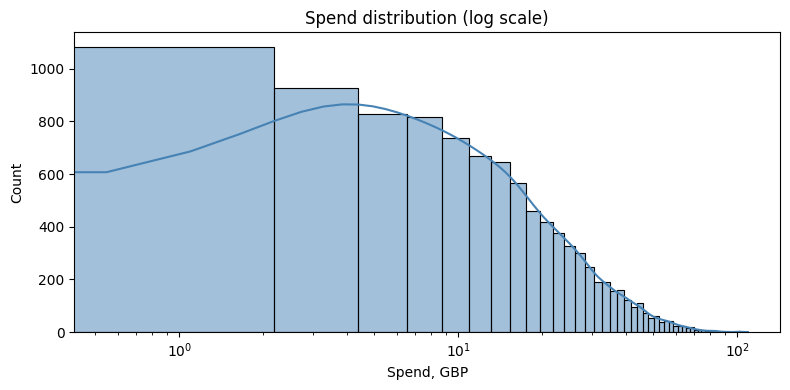

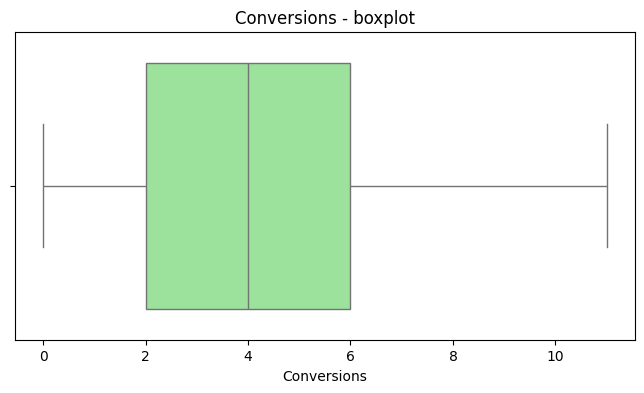

In [6]:
# Spend distribution (log scale)
plt.figure(figsize=(8,4))
sns.histplot(df['Spend, GBP'], bins=50, kde=True, color='steelblue')
plt.xscale('log')
plt.title('Spend distribution (log scale)')
plt.tight_layout()
plt.show()

# Conversions distribution
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Conversions'], color='lightgreen')
plt.title('Conversions - boxplot')
plt.show()

## Executive Interpretation
Write concise bullet points explaining what happened and recommended next steps.

In [7]:
print('Executive Summary:')
print('- Majority of impressions concentrated in a few campaigns; conversions are skewed.')
print('- Channel-level performance shows where conversions are efficient (high conversion rate & lower CPC).')
print('- Spend distribution is right-skewed; a small number of placements consume most budget.')
print('- Recommend reallocating budget to top ROI campaigns and channels; increase testing on underperforming creatives.')

Executive Summary:
- Majority of impressions concentrated in a few campaigns; conversions are skewed.
- Channel-level performance shows where conversions are efficient (high conversion rate & lower CPC).
- Spend distribution is right-skewed; a small number of placements consume most budget.
- Recommend reallocating budget to top ROI campaigns and channels; increase testing on underperforming creatives.
